### DSC 478 | Programming Machine Learning Applications | Spring 2026

#### Assignment-2 | Avni Sanghvi

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from collections import Counter
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

### 1. K-Nearest-Neighbor (KNN) classification on Newsgroups

#### For this problem you will use a subset of the 20 Newsgroup data set. The full data set contains 20,000 newsgroup documents, partitioned (nearly) evenly across 20 different newsgroups and has been often used for experiments in text applications of machine learning techniques, such as text classification and text clustering (see the description of the full dataset). The subset for this assignment includes 2,500 documents (newsgroup posts), each belonging to one of 5 categories windows (0), crypt (1), christian (2), hockey (3), forsale (4). The documents are represented by 9328 terms (stems). The dictionary (vocabulary) for the data set is given in the file "newsgroups5-terms.txt". The data has already been split into a 80% training set (newsgroups5-train.csv) and a 20% test set (newsgroups5-test.csv). The class labels for the training and test data are also provided in separate "label" files (with each row corresponding to the label for each test or training document). The training and test data are in document by term format, containing a row for each document in the vocabulary and a column for each term. The values in the table represent raw term occurrence counts for each document.

#### Your tasks in this problem are the following [Note: for this problem you should not use scikit-learn for classification, but implement your own KNN classifier. You may use Pandas, NumPy, standard Python libraries, and Matplotlib.]

#### 1a. Load the data sets, including the train and test matrices as well as the train and test labels. Show the top 20 terms in the decreasing order of total training frequency (total number of occurences of the term across all documents in the training data). Then plot the distribtution of term frequencies in the training data and in the test data (using a line plot similar to class examples).

In [2]:
# load the vocabulary
terms = pd.read_csv('newsgroups5-terms.txt', header=None, names=['Term'])

In [3]:
# load train set
train_set = pd.read_csv('newsgroups5-train.csv', header=None)

# load test set
test_set = pd.read_csv('newsgroups5-test.csv',header=None)

# load train labels
train_labels = pd.read_csv('newsgroups5-train-labels.csv', header=None)

# load test labels
test_labels = pd.read_csv('newsgroups5-test-labels.csv', header=None)

In [4]:
# top 20 terms with their training frequency
train_freq = train_set.sum(axis=0)
print(train_freq.sort_values(ascending=False).head(20))

547     37850
4982     2727
7895     2128
5795     1587
9129     1234
3345     1025
3266      992
4449      918
417       901
6049      890
9025      890
8203      851
4319      828
4364      807
3198      770
8255      746
3339      745
8033      665
3361      662
2933      625
dtype: int64


In [5]:
# test frequency
test_freq = test_set.sum(axis=0)

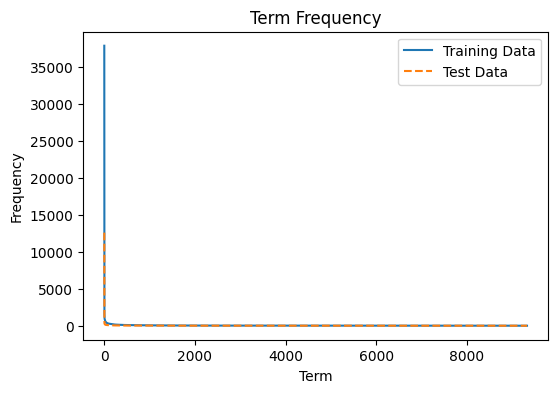

In [6]:
# plotting frequencies
plt.figure(figsize=(6,4))
plt.plot(sorted(train_freq, reverse=True), label = 'Training Data')
plt.plot(sorted(test_freq, reverse=True), label = 'Test Data', linestyle='--')
plt.title('Term Frequency')
plt.xlabel('Term')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [7]:
# fit the scaler to the training data
min_max_scaler = preprocessing.MinMaxScaler()
min_max_scaler.fit(train_set)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [8]:
# using the scaler to transform both train and test sets
train_norm = min_max_scaler.transform(train_set)
test_norm = min_max_scaler.transform(test_set)

In [9]:
# transforming the train and test labels as well

target_train = np.array(train_labels)
target_test = np.array(test_labels)

#### 1b. Create your own K-Nearest-Neighbor classifier function. Your classifier should allow as input the training data matrix, the training labels, the instance to be classified, the value of K (number of neighbors), and should return the predicted class for the instance and the indices of the top K neighbors. Your classifier should work with Euclidean distance as well as Cosine distance (which is 1 minus the Cosine similarity). You may create two separate classifiers, or add the distance metric as a parameter in the classifier function (an example implementation of a KNN classifier was provided in class examples). Show that your classifier works by running it on the first two instances in the test data using both Cosine and Euclidean distance in each case.

In [10]:
def knn_classifier(train_data, train_label, instance, k, measure):

    
    if measure == 0: # 0 is for euclidean distance
        distances = np.sqrt(((train_data - instance)**2).sum(axis=1))
        
    elif measure == 1: # 1 for cosine distance
        # finding vector norm for both train data and instance
        train_norm = np.array([np.linalg.norm(train_data[i]) for i in range(len(train_data))])
        instance_norm = np.linalg.norm(instance)
        denom = train_norm * instance_norm
        denom[denom == 0] = 1e-10
        
        # compute cosine similarity
        sims = np.dot(train_data, instance)/denom
        
        # compute distance
        distances = 1 - sims

    idx = np.argsort(distances) # sort
    top_k_idx = idx[:k]

    neighbor_labels = train_label[top_k_idx].flatten()

    # majority labels
    counts = Counter(neighbor_labels)

    # prediction by classifier
    prediction = counts.most_common(1)[0][0]

    # returning k nearest neighbors
    return prediction, top_k_idx

In [11]:
# Classifier on first two instances of test data
for i in [0,1]:
    test_instance = test_norm[i]
    true_label = target_test[i]
    
    for dist_type in [0,1]:
        measure = "Euclidean" if dist_type == 0 else "Cosine"
        pred, neighbors = knn_classifier(train_norm, target_train, test_instance,5,dist_type)
        print(f"Test Instance {i} | Metric: {measure} | Prediction: {pred} | Neighbors = \n {neighbors}")

Test Instance 0 | Metric: Euclidean | Prediction: 0 | Neighbors = 
 [ 908  338 1103 1924   44]
Test Instance 0 | Metric: Cosine | Prediction: 0 | Neighbors = 
 [ 908 1813  338  549  516]
Test Instance 1 | Metric: Euclidean | Prediction: 3 | Neighbors = 
 [1935  326 1542  809 1481]
Test Instance 1 | Metric: Cosine | Prediction: 3 | Neighbors = 
 [1935 1437  430 1352 1578]


#### 1c. Create an evaluation function to measure the accuracy of your classifier. This function will call the classifier function in part a on all the test instances and in each case compares the actual test class label to the predicted class label. It should take as input the training data, the training labels, the test instances, the labels for test instances, and the value of K. Your evaluation function should return the Classification Accuracy (ratio of correct predictions to the number of test instances) 

In [12]:
# evaluation function
def evaluate_knn(train_norm, target_train, test_norm, target_test, k, measure=0):
    train_label_arr = np.array(target_train).flatten()
    test_label_arr = np.array(target_test).flatten()

    numTestVecs = len(test_label_arr)
    correctCount = 0

    for i in range(numTestVecs):
        predicted, _ = knn_classifier(train_norm, train_label_arr, test_norm[i, :],k,measure)
        actual = test_label_arr[i]

        if predicted == actual:
            correctCount += 1

    accuracy = correctCount / numTestVecs
    return accuracy

In [13]:
# function call to get the accuracy

for measure, name in  [(0, "Euclidean"), (1, "Cosine")]:
    acc = evaluate_knn(train_norm, train_labels, test_norm, test_labels, k=3, measure=measure)
    print(f"Metric: {name} | Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Metric: Euclidean | Accuracy: 0.5400 (54.00%)
Metric: Cosine | Accuracy: 0.8560 (85.60%)


#### 1d. Run your evaluation function on a range of values for K from 5 to 100 (in increments of 5) in order to compare accuracy values for different numbers of neighbors. Do this both using Euclidean Distance as well as Cosine similarity measure. Present the results as graphs with K in the x-axis and the evaluation metric (accuracy) on the y-axis. Use a single plot to compare the two version of the classifier

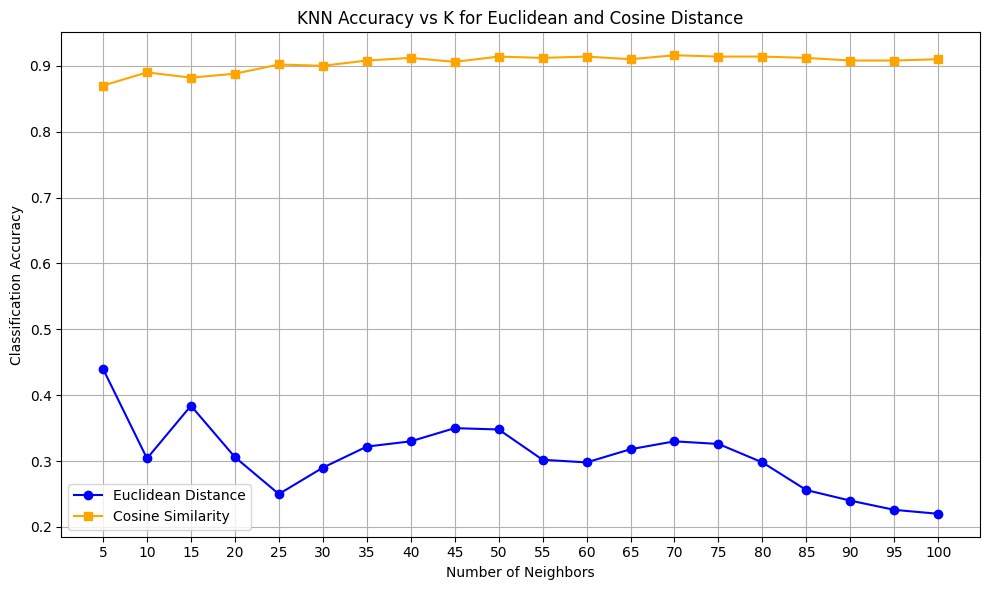

In [14]:
k_values = range(5,101,5)

euclidean_accuracies = []
cosine_accuracies = []

# evalaution from k=5 to k=100, in steps of 5
for k in k_values:
    acc_euc = evaluate_knn(train_norm, train_labels, test_norm, test_labels, k=k, measure=0)
    acc_cos = evaluate_knn(train_norm, train_labels, test_norm, test_labels, k=k, measure=1)
    euclidean_accuracies.append(acc_euc)
    cosine_accuracies.append(acc_cos)

plt.figure(figsize=(10,6))
plt.plot(k_values, euclidean_accuracies, marker='o', label='Euclidean Distance', color='blue')
plt.plot(k_values, cosine_accuracies, marker='s', label='Cosine Similarity', color='orange')
plt.xlabel('Number of Neighbors')
plt.ylabel('Classification Accuracy')
plt.title('KNN Accuracy vs K for Euclidean and Cosine Distance')
plt.legend()
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

#### 1e. Next, modify the training and test data sets so that term weights are converted to TFxIDF weights (instead of raw term frequencies). Then, rerun your evaluation (only for the Cosine similarity version of the classifier) on the range of K values (as above) and create a chart comparing the results with and without using TFxIDF weights.

#### For training data set

In [15]:
numTerms_train = train_set.shape[1]
NDocs_train = train_set.shape[0]

In [16]:
print(numTerms_train)
print(NDocs_train)

9328
2000


In [17]:
# doc frequency for each term
DF_train = pd.DataFrame([(train_set!=0).sum(0)])

/var/folders/rl/9117cff57ybbssjgmwf5m79c0000gn/T/ipykernel_47093/2179159564.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  DF_train = pd.DataFrame([(train_set!=0).sum(0)])


In [18]:
DF_train

,0,1,2,3,4,5,6,7,8,9,...,9318,9319,9320,9321,9322,9323,9324,9325,9326,9327
0,8,5,18,7,12,8,21,2,42,145,...,6,4,3,4,2,4,4,2,2,4


In [19]:
# create a matrix with all entries = NDocs
NMatrix_train = np.ones(np.shape(train_set), dtype=float)*NDocs_train
np.set_printoptions(precision=2,suppress=True,linewidth=120)
print(NMatrix_train)

[[2000. 2000. 2000. ... 2000. 2000. 2000.]
 [2000. 2000. 2000. ... 2000. 2000. 2000.]
 [2000. 2000. 2000. ... 2000. 2000. 2000.]
 ...
 [2000. 2000. 2000. ... 2000. 2000. 2000.]
 [2000. 2000. 2000. ... 2000. 2000. 2000.]
 [2000. 2000. 2000. ... 2000. 2000. 2000.]]


In [20]:
# convert each entry into IDF values
IDF_train = np.log2(np.divide(NMatrix_train, np.array(DF_train)))

/var/folders/rl/9117cff57ybbssjgmwf5m79c0000gn/T/ipykernel_47093/1969272823.py:2: RuntimeWarning: divide by zero encountered in divide
  IDF_train = np.log2(np.divide(NMatrix_train, np.array(DF_train)))


In [21]:
#TF-IDF value for each entry

tfidf_train = train_set * IDF_train

In [22]:
pd.set_option("display.precision", 2)

tfidf_train

,0,1,2,3,4,5,6,7,8,9,...,9318,9319,9320,9321,9322,9323,9324,9325,9326,9327
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### For test data set

In [23]:
numTerms_test = test_set.shape[1]
NDocs_test = test_set.shape[0]

In [24]:
print(numTerms_test)
print(NDocs_test)

9328
500


In [25]:
# doc frequency for each term
DF_test = pd.DataFrame([(test_set!=0).sum(0)])

/var/folders/rl/9117cff57ybbssjgmwf5m79c0000gn/T/ipykernel_47093/4176900748.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  DF_test = pd.DataFrame([(test_set!=0).sum(0)])


In [26]:
DF_test

,0,1,2,3,4,5,6,7,8,9,...,9318,9319,9320,9321,9322,9323,9324,9325,9326,9327
0,2,1,4,2,1,1,9,1,14,27,...,1,1,0,2,1,2,1,1,1,0


In [27]:
# create a matrix with all entries = NDocs
NMatrix_test = np.ones(np.shape(test_set), dtype=float)*NDocs_test
np.set_printoptions(precision=2,suppress=True,linewidth=120)
print(NMatrix_test)

[[500. 500. 500. ... 500. 500. 500.]
 [500. 500. 500. ... 500. 500. 500.]
 [500. 500. 500. ... 500. 500. 500.]
 ...
 [500. 500. 500. ... 500. 500. 500.]
 [500. 500. 500. ... 500. 500. 500.]
 [500. 500. 500. ... 500. 500. 500.]]


In [28]:
# convert each entry into IDF values
IDF_test = np.log2(np.divide(NMatrix_test, np.array(DF_test)))

/var/folders/rl/9117cff57ybbssjgmwf5m79c0000gn/T/ipykernel_47093/2776037917.py:2: RuntimeWarning: divide by zero encountered in divide
  IDF_test = np.log2(np.divide(NMatrix_test, np.array(DF_test)))


In [29]:
#TF-IDF value for each entry

tfidf_test = test_set * IDF_test

In [30]:
pd.set_option("display.precision", 2)

tfidf_test

,0,1,2,3,4,5,6,7,8,9,...,9318,9319,9320,9321,9322,9323,9324,9325,9326,9327
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN
496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN
497,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN
498,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.21,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN


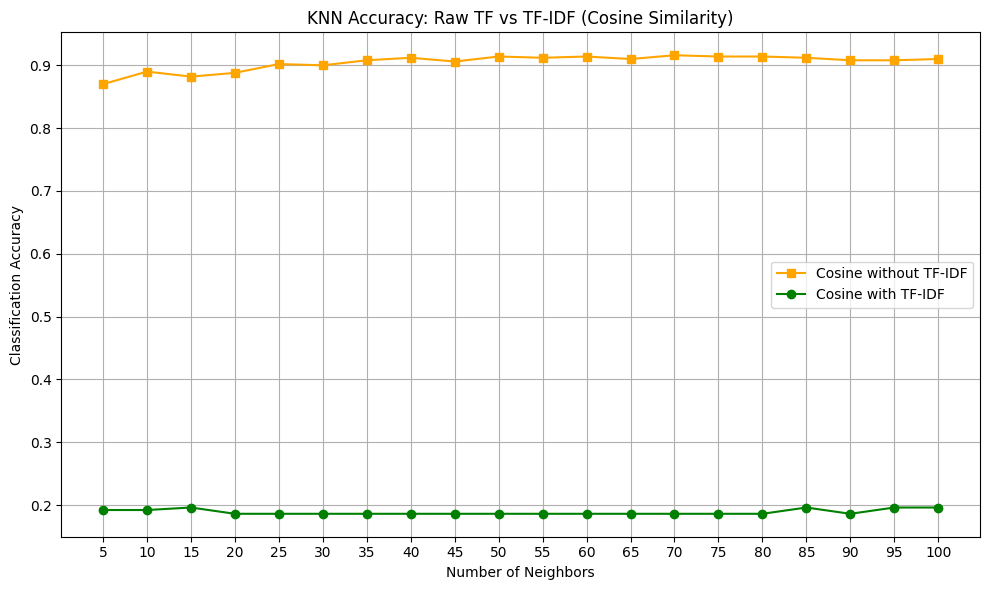

In [31]:
tfidf_train_arr = np.array(tfidf_train)
tfidf_test_arr = np.array(tfidf_test)

k_values = range(5, 101, 5)
cosine_accuracies_tfidf = []

for k in k_values:
    acc = evaluate_knn(tfidf_train_arr, train_labels, tfidf_test_arr, test_labels, k=k, measure=1)
    cosine_accuracies_tfidf.append(acc)

# Plot comparing with and without TF-IDF
plt.figure(figsize=(10, 6))
plt.plot(k_values, cosine_accuracies, marker='s', label='Cosine without TF-IDF', color='orange')
plt.plot(k_values, cosine_accuracies_tfidf, marker='o', label='Cosine with TF-IDF', color='green')

plt.xlabel('Number of Neighbors')
plt.ylabel('Classification Accuracy')
plt.title('KNN Accuracy: Raw TF vs TF-IDF (Cosine Similarity)')
plt.legend()
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

#### 1f. Create a new classifier based on the Rocchio Method (also know as the "nearest centroid" method) adapted for text categorization. You should separate the training function from the classification function. The training part for the classifier can be implemented as a function that takes as input the training data matrix and the training labels, returning the prototype vectors for each class. The classification part can be implemented as another function that would take as input the prototypes returned from the training function and the instance to be classified. This function should measure Cosine similarity of the test instance to each prototype vector. Your output should indicate the predicted class for the test instance and the similarity values of the instance to each of the category prototypes.  Finally, use your evaluation function to compare your results to the best KNN results you obtained in part d. [Note: your functions should work regardless of the number of categories (class labels) and should not be limited to two-class categorization scenario. The number of classes should not be hardcoded in your implementation.]

In [32]:
def rocchio_train(train_data, train_labels):
    train_data_arr = np.array(train_data)
    train_labels_arr = np.array(train_labels).flatten()
    
    classes = np.unique(train_labels_arr)
    prototypes = {}
    
    for cls in classes:
        # get all training instances belonging to this class
        class_mask = train_labels_arr == cls
        class_instances = train_data_arr[class_mask]
        # prototype is the mean of all instances in the class
        prototypes[cls] = class_instances.mean(axis=0)
    
    return prototypes

In [33]:
def rocchio_classify(prototypes, instance):
    similarities = {}
    
    instance_norm = np.linalg.norm(instance)
    
    for cls, prototype in prototypes.items():
        proto_norm = np.linalg.norm(prototype)
        denom = instance_norm * proto_norm
        if denom == 0:
            similarities[cls] = 0.0
        else:
            similarities[cls] = np.dot(instance, prototype) / denom
    
    # predicted class is the one with highest cosine similarity
    predicted_class = max(similarities, key=lambda cls: similarities[cls])
    
    return predicted_class, similarities

The previously created evaluation function won't work here because it uses knn_classifier but here it is asked for rocchio methods. So I have created a new function with same logic of calculating accuracy.

In [34]:
def evaluate_rocchio(prototypes, test_data, test_labels):
    test_data_arr = np.array(test_data)
    test_labels_arr = np.array(test_labels).flatten()
    
    numTestVecs = len(test_labels_arr)
    correctCount = 0
    
    for i in range(numTestVecs):
        predicted, similarities = rocchio_classify(prototypes, test_data_arr[i, :])
        if predicted == test_labels_arr[i]:
            correctCount += 1
    
    return correctCount / numTestVecs

In [35]:
# to handle NaN

tfidf_train_arr = np.nan_to_num(np.array(tfidf_train), nan=0.0)
tfidf_test_arr  = np.nan_to_num(np.array(tfidf_test), nan=0.0)

In [36]:
# Train Rocchio on both raw TF and TF-IDF
prototypes_tf    = rocchio_train(train_norm, train_labels)       # raw TF (scaled)
prototypes_tfidf = rocchio_train(tfidf_train_arr, train_labels)  # TF-IDF

# Evaluate
acc_rocchio_tf    = evaluate_rocchio(prototypes_tf, test_norm, test_labels)
acc_rocchio_tfidf = evaluate_rocchio(prototypes_tfidf, tfidf_test_arr, test_labels)

print(f"Rocchio Accuracy (Raw TF):  {acc_rocchio_tf:.4f} ({acc_rocchio_tf*100:.2f}%)")
print(f"Rocchio Accuracy (TF-IDF):  {acc_rocchio_tfidf:.4f} ({acc_rocchio_tfidf*100:.2f}%)")

Rocchio Accuracy (Raw TF):  0.9440 (94.40%)
Rocchio Accuracy (TF-IDF):  0.7980 (79.80%)


#### 1g. Using scikit-learn's Nearest Centroid classifier to perform classification of the test instances as in the previous part. Compare the classification accuracy of your Rocchio implementation to the classification results using scikit-learn.

In [37]:
nc_tf    = NearestCentroid(metric='euclidean')
nc_tfidf = NearestCentroid(metric='euclidean')

nc_tf.fit(train_norm, train_labels.values.flatten())
nc_tfidf.fit(tfidf_train_arr, train_labels.values.flatten())

/opt/miniconda3/lib/python3.13/site-packages/sklearn/neighbors/_nearest_centroid.py:241: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/neighbors/_nearest_centroid.py:241: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(


,"metric metric: {""euclidean"", ""manhattan""}, default=""euclidean""Metric to use for distance computation.If `metric=""euclidean""`, the centroid for the samples corresponding to eachclass is the arithmetic mean, which minimizes the sum of squared L1 distances.If `metric=""manhattan""`, the centroid is the feature-wise median, whichminimizes the sum of L1 distances... versionchanged:: 1.5 All metrics but `""euclidean""` and `""manhattan""` were deprecated and now raise an error... versionchanged:: 0.19 `metric='precomputed'` was deprecated and now raises an error",'euclidean'
,"shrink_threshold shrink_threshold: float, default=NoneThreshold for shrinking centroids to remove features.",None
,"priors priors: {""uniform"", ""empirical""} or array-like of shape (n_classes,), default=""uniform""The class prior probabilities. By default, the class proportions areinferred from the training data... versionadded:: 1.6",'uniform'


In [38]:
# Evaluation
acc_sklearn_tf    = accuracy_score(test_labels, nc_tf.predict(test_norm))
acc_sklearn_tfidf = accuracy_score(test_labels, nc_tfidf.predict(tfidf_test_arr))

In [39]:
print(acc_sklearn_tf)
print(acc_sklearn_tfidf)

0.826
0.552


In [40]:
# comparison with rocchio
print(f"Sklearn Nearest Centroid Accuracy (Raw TF):  {acc_sklearn_tf:.4f}")
print(f"Sklearn Nearest Centroid Accuracy (TF-IDF):  {acc_sklearn_tfidf:.4f}")
print(f"Our Rocchio Accuracy (Raw TF):               {acc_rocchio_tf:.4f}")
print(f"Our Rocchio Accuracy (TF-IDF):               {acc_rocchio_tfidf:.4f}")

Sklearn Nearest Centroid Accuracy (Raw TF):  0.8260
Sklearn Nearest Centroid Accuracy (TF-IDF):  0.5520
Our Rocchio Accuracy (Raw TF):               0.9440
Our Rocchio Accuracy (TF-IDF):               0.7980


### 2. Predictive Modeling with Census data

#### For this problem you will use a version of the Adult Census Data Set you used in the previous assignment. In the subset provided here, some of the attributes have been removed and some preprocessing has been performed.

#### 2a. Load the data into a Pandas dataframe. Create dummy variables for the categorical attributes. Then separate the attribute ("income_>50K") from the remaining attributes; this will be used as the target attribute for classification.  [Note: you need to drop "income_<=50K" which is also created as a dummy variable in earlier step]. Finally, split the transformed data into training and test sets (using 80%-20% randomized split). Note: use the train_test_split function from the sklearn.model_selection module with random_state = 111 to perform the split.

In [41]:
# loading the data set
adult = pd.read_csv('adult-sample-04-20-2026.csv')

In [42]:
#size of the data set
adult.shape

(11300, 9)

In [43]:
# columns in the data set
adult.columns

Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation',
       'race', 'sex', 'hours-per-week', 'income'],
      dtype='str')

In [44]:
# few rows of the data
adult.head()

,age,workclass,education-num,marital-status,occupation,race,sex,hours-per-week,income
0,45.0,Private,10.0,Divorced,Adm-clerical,Black,Female,32.0,<=50K
1,58.0,Self-employed,4.0,Married,Transport-moving,White,Male,40.0,>50K
2,42.0,Private,14.0,Divorced,Adm-clerical,White,Female,25.0,<=50K
3,40.0,Public,9.0,Married,Craft-repair,White,Male,40.0,<=50K
4,58.0,Private,10.0,Married,Sales,Black,Male,40.0,<=50K


In [45]:
# missing values check
adult.isnull().sum()

age               493
workclass         493
education-num     493
marital-status    493
occupation        493
race              493
sex               493
hours-per-week    493
income            493
dtype: int64

In [46]:
# Numeric columns impute with MEAN 
adult['age']           = adult['age'].fillna(adult['age'].mean())
adult['hours-per-week']= adult['hours-per-week'].fillna(adult['hours-per-week'].mean())

In [47]:
# Categorical columns with mode
adult['workclass']     = adult['workclass'].fillna(adult['workclass'].mode()[0])
adult['marital-status']= adult['marital-status'].fillna(adult['marital-status'].mode()[0])
adult['occupation']    = adult['occupation'].fillna(adult['occupation'].mode()[0])
adult['race']          = adult['race'].fillna(adult['race'].mode()[0])
adult['sex']           = adult['sex'].fillna(adult['sex'].mode()[0])
adult['income']        = adult['income'].fillna(adult['income'].mode()[0])
adult['education-num'] = adult['education-num'].fillna(adult['education-num'].mode()[0])

In [48]:
#verify the imputation
adult.isnull().sum()

age               0
workclass         0
education-num     0
marital-status    0
occupation        0
race              0
sex               0
hours-per-week    0
income            0
dtype: int64

In [49]:
# create dummy variables
adult_dummies = pd.get_dummies(adult)

In [50]:
adult_dummies.head()

,age,education-num,hours-per-week,workclass_Private,workclass_Public,workclass_Self-employed,workclass_Without-pay,marital-status_Divorced,marital-status_Married,marital-status_Married-spouse-absent,...,occupation_Transport-moving,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,income_<=50K,income_>50K
0,45.0,10.0,32.0,True,False,False,False,True,False,False,...,False,False,False,True,False,False,True,False,True,False
1,58.0,4.0,40.0,False,False,True,False,False,True,False,...,True,False,False,False,False,True,False,True,False,True
2,42.0,14.0,25.0,True,False,False,False,True,False,False,...,False,False,False,False,False,True,True,False,True,False
3,40.0,9.0,40.0,False,True,False,False,False,True,False,...,False,False,False,False,False,True,False,True,True,False
4,58.0,10.0,40.0,True,False,False,False,False,True,False,...,False,False,False,True,False,False,False,True,True,False


In [51]:
# target column
y = adult_dummies['income_>50K']

# features
x = adult_dummies.drop(columns=['income_>50K', 'income_<=50K'])

In [52]:
# splitting into training and testing set
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=111)

#### 2b. Use scikit-learn's KNN implementation for classification.
1. **First normalize the data so that all attributes are in the same scale (normalize so that the values are between 0 and 1). Run your KNN classifier using K=10. Generate the confusion matrix (visualize it using Matplotlib) as well as the classification report. Report the model accuracy for both the training and the test sets.**
2. **Next, experiment with different values of K (say from 5 to 100) and the weight parameter (i.e., with or without distance weighting) to see if you can improve accuracy of the KNN classifier. Show the results in a single plot comparing distance and uniform weighting schemes across the different values of K. Use the best values of these hyperparameters (K and weighting scheme) to train a new KNN classifier and report the accuracy of this classifier on the training and test sets.**
3. **Next, using only "uniform" weights, compare the accuracy of the KNN classifier across the different values of K on the training and the test data. You should show the results in a single figure with two line plots for the test and training accuracy values (y-axis) and with values of K in the x-axis. Your figure may look similar (but bit not exactly the same) as depicted in this image.What range of values of K represent overfitting? Briefly explain.**

#### 2b.1

In [53]:
# normalize the data
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [54]:
# classifier with k=10
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [55]:
# prediction with classifier
y_train_pred = knn.predict(x_train_scaled)
y_test_pred = knn.predict(x_test_scaled)

In [56]:
# accuracy of classifier
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test,y_test_pred)

print(f"Training Accuracy: , {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Testing Accuracy: , {test_acc:.4f} ({test_acc*100:.2f}%)")

Training Accuracy: , 0.8493 (84.93%)
Testing Accuracy: , 0.8345 (83.45%)


In [57]:
# classification report
print("\nClassification Report: ")
print(classification_report(y_test,y_test_pred,target_names=['<=50K', '>50K']))


Classification Report: 
              precision    recall  f1-score   support

       <=50K       0.86      0.93      0.89      1715
        >50K       0.70      0.54      0.61       545

    accuracy                           0.83      2260
   macro avg       0.78      0.73      0.75      2260
weighted avg       0.83      0.83      0.83      2260



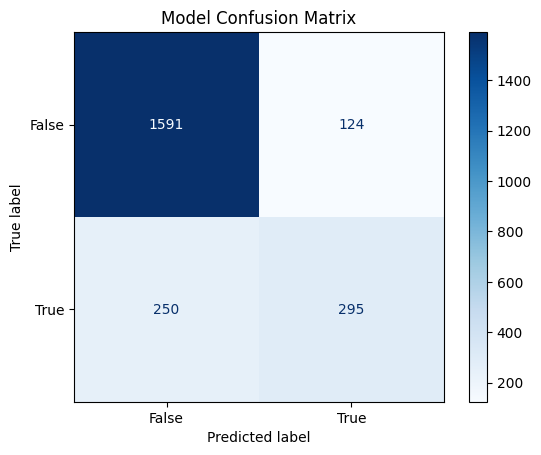

In [58]:
# visualizing confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)

# Plot the matrix
disp.plot(cmap=plt.cm.Blues)

plt.title("Model Confusion Matrix")
plt.show()

#### 2b.2

In [59]:
k_values = range(5,101,5)
weights = ['uniform', 'distance']
results    = {w: {'train': [], 'test': []} for w in weights}

for w in weights:
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, weights=w)
        knn.fit(x_train_scaled, y_train)
        results[w]['train'].append(accuracy_score(y_train, knn.predict(x_train_scaled)))
        results[w]['test'].append(accuracy_score(y_test,  knn.predict(x_test_scaled)))

In [60]:
# best hyperparamters
best = {'acc':0}

for w in weights:
    for i, k in enumerate(k_values):
        acc = results[w]['test'][i]
        if acc > best['acc']:
            best = {'acc': acc, 'k': k, 'w': w, 'i': i}

print(f"  Best K       : {best['k']}")
print(f"  Best Weights : {best['w']}")
print(f"  Best Test Acc: {best['acc']*100:.2f}%")

  Best K       : 10
  Best Weights : uniform
  Best Test Acc: 83.45%


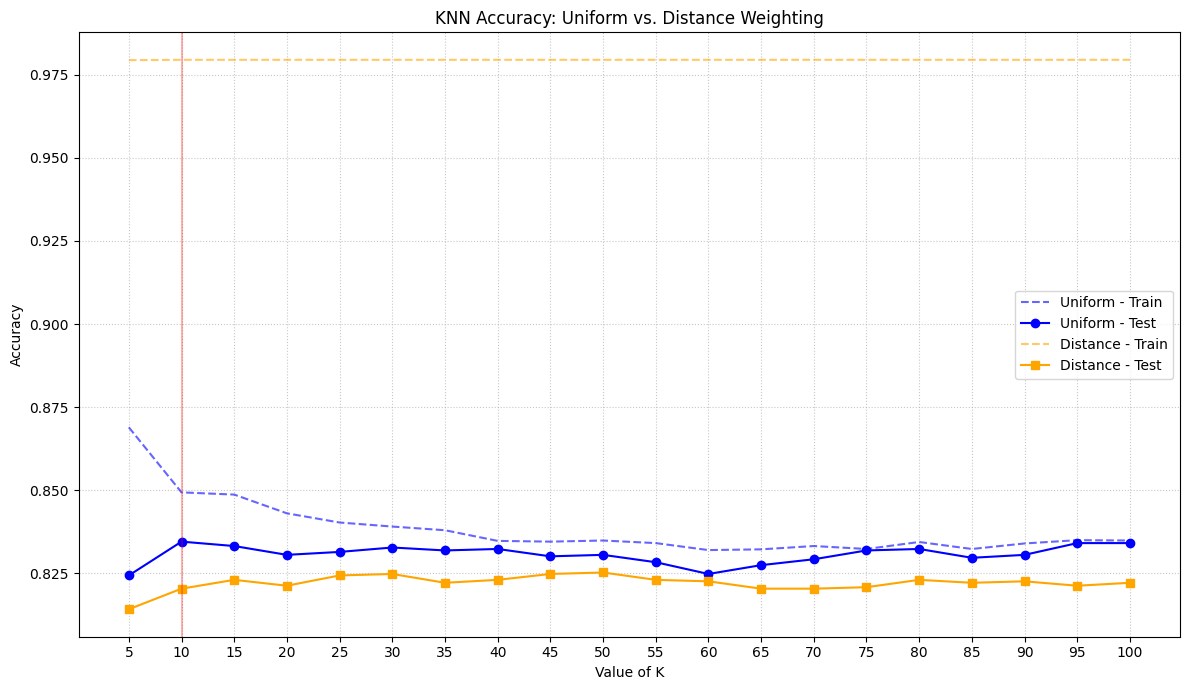

In [61]:
# plotting

plt.figure(figsize=(12, 7))

# Plotting Uniform weights
plt.plot(k_values, results['uniform']['train'], label='Uniform - Train', linestyle='--', color='blue', alpha=0.6)
plt.plot(k_values, results['uniform']['test'], label='Uniform - Test', marker='o', color='blue')

# Plotting Distance weights
plt.plot(k_values, results['distance']['train'], label='Distance - Train', linestyle='--', color='orange', alpha=0.6)
plt.plot(k_values, results['distance']['test'], label='Distance - Test', marker='s', color='orange')

# Adding labels and title
plt.title('KNN Accuracy: Uniform vs. Distance Weighting')
plt.xlabel('Value of K')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Highlight the best point
plt.axvline(x=best['k'], color='red', linestyle='-', alpha=0.3, label=f"Best K={best['k']}")

plt.tight_layout()
plt.show()

In [62]:
# Training the model with best values of hyperparameters
print(f"\nTraining best KNN : K={best['k']}, weights='{best['w']}'")
knn_best = KNeighborsClassifier(n_neighbors=best['k'], weights=best['w'])
knn_best.fit(x_train_scaled, y_train)
 
y_train_pred = knn_best.predict(x_train_scaled)
y_test_pred  = knn_best.predict(x_test_scaled)
 
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print(f"  Best Model Training Accuracy : {train_acc*100:.2f}%")
print(f"  Best Model Test     Accuracy : {test_acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['<=50K', '>50K']))


Training best KNN : K=10, weights='uniform'
  Best Model Training Accuracy : 84.93%
  Best Model Test     Accuracy : 83.45%

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.86      0.93      0.89      1715
        >50K       0.70      0.54      0.61       545

    accuracy                           0.83      2260
   macro avg       0.78      0.73      0.75      2260
weighted avg       0.83      0.83      0.83      2260



#### 2b.3

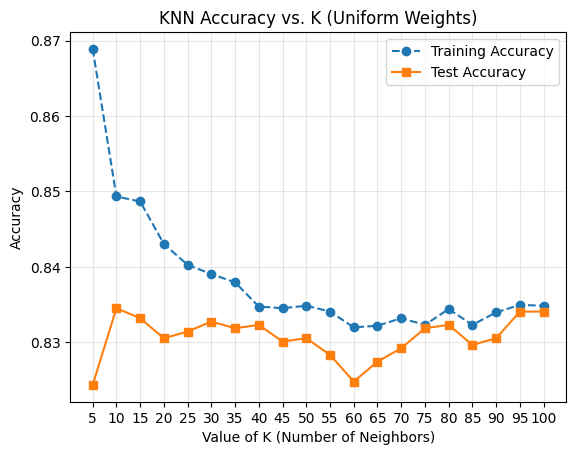

In [63]:
# Extract data for uniform weighting
train_acc = results['uniform']['train']
test_acc = results['uniform']['test']

# Plot training and test accuracy
plt.plot(k_values, train_acc, label='Training Accuracy', marker='o', linestyle='--')
plt.plot(k_values, test_acc, label='Test Accuracy', marker='s', linestyle='-')

# Formatting the plot
plt.title('KNN Accuracy vs. K (Uniform Weights)')
plt.xlabel('Value of K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Overfitting is seen when the training accuracy is very high as compared to the testing accuracy.

This means that the model is memorizing the data and is not generalizing it and hence it fails on unseen data.

In the achieved plot, values of k=5 to 20, shows the zone of overfitting.

At k=5, the training accuracy is at its peak and test accuracy is very low, close to 82%

#### 2c. Using the non-normalized training and test data, perform classification using scikit-learn's decision tree classifier (using the default parameters). As above, generate the confusion matrix, classification report, and average accuracy scores of the classifier. Compare the average accuracy score on the test and the training data sets. What does the comparison tell you in terms of bias-variance trade-off? Next, create another decision tree model (trained on the non-normalized training data) using "gini" index as the selection criteria, min_samples_split=10, and max_depth=4. Show the accuracy results for both the training and test sets.

DEFAULT DECISION TREE:
  Training Accuracy : 97.95%
  Test     Accuracy : 77.08%

Classification Report (Test Set):
              precision    recall  f1-score   support

       <=50K       0.85      0.85      0.85      1715
        >50K       0.53      0.51      0.52       545

    accuracy                           0.77      2260
   macro avg       0.69      0.68      0.68      2260
weighted avg       0.77      0.77      0.77      2260



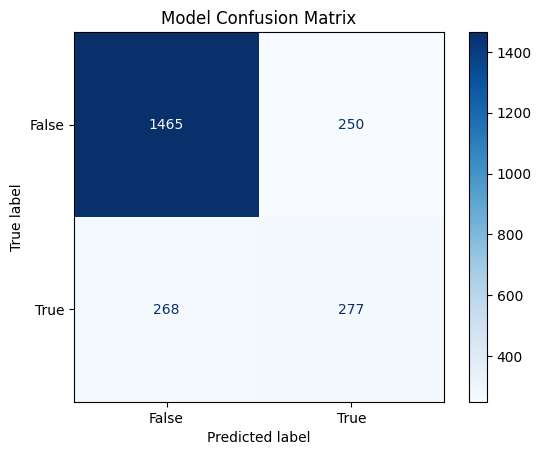

In [64]:
# Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=111)
dt.fit(x_train, y_train)

# prediction with decision tree
y_train_pred = dt.predict(x_train)
y_test_pred  = dt.predict(x_test)

# accuracy score of the decision tree
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print("DEFAULT DECISION TREE:")
print(f"  Training Accuracy : {train_acc*100:.2f}%")
print(f"  Test     Accuracy : {test_acc*100:.2f}%")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['<=50K', '>50K']))

# confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt.classes_)

# Plot the matrix
disp.plot(cmap=plt.cm.Blues)
plt.title("Model Confusion Matrix")
plt.show()

The decision tree is giving a very high training accuracy and a very little testing accuracy. The big difference between the with training accuracy high is a sign of overfitting.

The model is memorizing the data and it fails to generalize the unseen data and uncover the pattern within it.

This tree is allowed to grow without any max depth , which leads to splitting of all nodes until all the leaves are pure. Hence, the overfitting is observed.

  TUNED DECISION TREE (gini, min_samples_split=10, max_depth=4)
  Training Accuracy : 83.13%
  Test     Accuracy : 81.99%

Classification Report (Test Set):
              precision    recall  f1-score   support

       <=50K       0.84      0.94      0.89      1715
        >50K       0.70      0.44      0.54       545

    accuracy                           0.82      2260
   macro avg       0.77      0.69      0.71      2260
weighted avg       0.81      0.82      0.80      2260



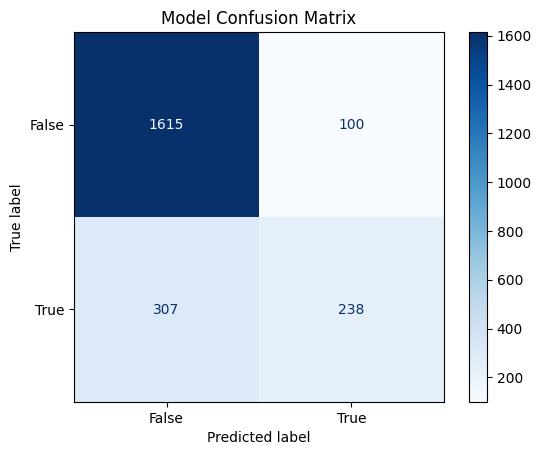

In [65]:
# hyper parameter tuning on decision tree
dt_tuned = DecisionTreeClassifier(criterion='gini', min_samples_split=10,
                                   max_depth=4, random_state=111)
dt_tuned.fit(x_train, y_train)

# prediction with the tree
y_test_pred_t  = dt_tuned.predict(x_test)

# accuracy score of the tree
train_acc_t = accuracy_score(y_train, dt_tuned.predict(x_train))
test_acc_t  = accuracy_score(y_test,  dt_tuned.predict(x_test))

print("  TUNED DECISION TREE (gini, min_samples_split=10, max_depth=4)")
print(f"  Training Accuracy : {train_acc_t*100:.2f}%")
print(f"  Test     Accuracy : {test_acc_t*100:.2f}%")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_t, target_names=['<=50K', '>50K']))

# confusion matrix
cm = confusion_matrix(y_test, y_test_pred_t)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_tuned.classes_)

# Plot the matrix
disp.plot(cmap=plt.cm.Blues)
plt.title("Model Confusion Matrix")
plt.show()


With hyper-parameter tuning on the tree, the difference between the accuracy score of training and testing set has reduced. The difference is very less, which shows that the overfitting has been overcomed.

The difference is still there, but since it is little, so it can be said that there is no overfitting in the model. In other words, the model is now able to uncover pattern and is able to generalize the unseen data as well.

#### 2d. Use scikit-learn to build classifiers using Naive Bayes (Gaussian) and linear discriminant analysis (LDA).  For each of these perform 10-fold cross-validation on the 80% training data (using cross-validation module in scikit-learn) and report the overall average accuracy. Compare this cross-validation accuracy to the model accuracy on the training data as a whole. Finally, run your model on the set-aside 20% test data.

In [66]:
# Naive Bayes (Gaussian) Classification
nb = GaussianNB()

# 10-fold cross-validation 
nb_cv_scores = cross_val_score(nb, x_train, y_train, cv=10)
nb_avg_cv = np.mean(nb_cv_scores)

# Model accuracy on the training data as a whole
nb.fit(x_train, y_train)
nb_train_acc = accuracy_score(y_train, nb.predict(x_train))

# Final model accuracy on 20% test data
nb_test_acc = accuracy_score(y_test, nb.predict(x_test))

print(f"GNB - Average CV Accuracy: {nb_avg_cv:.4f}")
print(f"GNB - Full Training Accuracy: {nb_train_acc:.4f}")
print(f"GNB - Test Set Accuracy: {nb_test_acc:.4f}")

GNB - Average CV Accuracy: 0.5479
GNB - Full Training Accuracy: 0.5561
GNB - Test Set Accuracy: 0.5646


In [67]:
# LDA
# LDA model
lda = LinearDiscriminantAnalysis()

# 10-fold cross-validation 
lda_cv_scores = cross_val_score(lda, x_train, y_train, cv=10)
lda_avg_cv = np.mean(lda_cv_scores)

# Model accuracy on the training data as a whole
lda.fit(x_train, y_train)
lda_train_acc = accuracy_score(y_train, lda.predict(x_train))

# Final model accuracy on 20% test data
lda_test_acc = accuracy_score(y_test, lda.predict(x_test))

print(f"LDA - Average CV Accuracy: {lda_avg_cv:.4f}")
print(f"LDA - Full Training Accuracy: {lda_train_acc:.4f}")
print(f"LDA - Test Set Accuracy: {lda_test_acc:.4f}")

LDA - Average CV Accuracy: 0.8289
LDA - Full Training Accuracy: 0.8311
LDA - Test Set Accuracy: 0.8332
